In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
ACTIONS = np.array([[-1, 0.8], [0, 1.0], [1, 0.8]], dtype=float)  # steer, throttle
POP_SIZE, GENE_LENGTH, GENERATIONS = 60, 30, 40
MUTATION_RATE = 0.08

def simulate(genome):
    position, speed, heading = 0.0, 0.0, 0.0
    collisions = 0
    steering_cost = 0.0
    for gene in genome:
        steer, throttle = ACTIONS[gene]
        heading += 0.10 * steer
        speed = np.clip(speed + 0.08 * throttle - 0.03, 0, 2.0)
        position += speed * np.cos(heading)
        steering_cost += abs(steer)
        if abs(heading) > 0.9:
            collisions += 1
            heading *= 0.85
    fitness = position - 1.5*collisions - 0.02*steering_cost
    return fitness, position, collisions


In [3]:
def initial_population():
    return np.random.randint(0, len(ACTIONS), size=(POP_SIZE, GENE_LENGTH))

def crossover(p1, p2):
    point = np.random.randint(1, GENE_LENGTH-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutate(g):
    g = g.copy()
    mask = np.random.rand(GENE_LENGTH) < MUTATION_RATE
    g[mask] = np.random.randint(0, len(ACTIONS), mask.sum())
    return g

pop = initial_population()
best_history = []
for gen in range(GENERATIONS):
    scored = sorted([(simulate(g)[0], g) for g in pop], key=lambda x: x[0], reverse=True)
    elites = [g for _, g in scored[:8]]
    best_history.append(scored[0][0])
    new_pop = elites.copy()
    while len(new_pop) < POP_SIZE:
        p1, p2 = elites[np.random.randint(len(elites))], elites[np.random.randint(len(elites))]
        new_pop.append(mutate(crossover(p1, p2)))
    pop = np.array(new_pop)

best = max(pop, key=lambda g: simulate(g)[0])
print('Best fitness:', simulate(best)[0])
print('Forward progress:', simulate(best)[1])
print('Collisions:', simulate(best)[2])


Best fitness: 23.24999999999999
Forward progress: 23.24999999999999
Collisions: 0


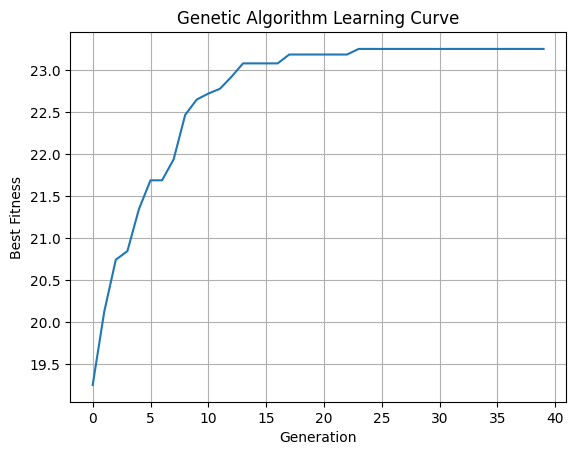

In [4]:
plt.plot(best_history)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.title('Genetic Algorithm Learning Curve')
plt.grid(True)
plt.show()


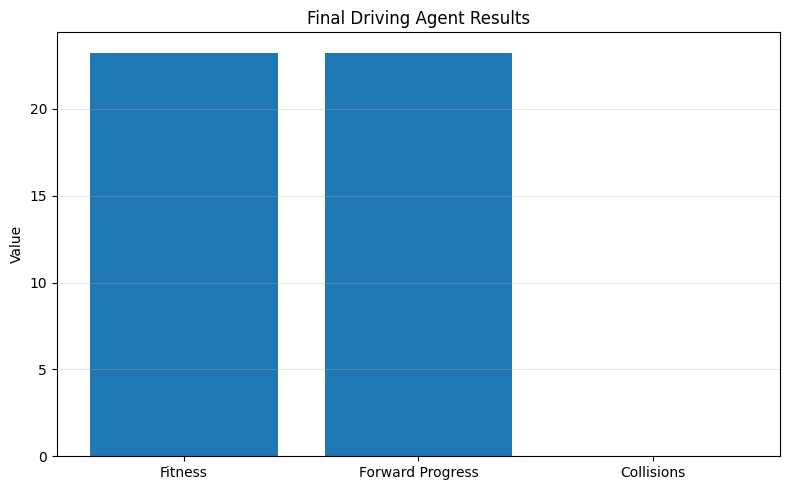

In [5]:
final_fitness, final_progress, final_collisions = simulate(best)
labels = ["Fitness", "Forward Progress", "Collisions"]
values = [final_fitness, final_progress, final_collisions]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.ylabel("Value")
plt.title("Final Driving Agent Results")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()